In [42]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import os
from tensorflow.keras.models import Model
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
import random
import seaborn as sns
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [ ]:
train_path = r"C:\Users\trainset"
test_path = r"C:\Users\testset"

In [29]:
target_size = (75, 75)
batch_size = 32
num_classes = 7

In [30]:
train_datagen = ImageDataGenerator(rescale=1./255,               # Normalize pixel values from [0, 255] to [0, 1]
                                    rotation_range=15,            # Randomly rotate images in the range of ±15 degrees
                                    width_shift_range=0.1,        # Randomly shift images horizontally by up to 10% of the width
                                    height_shift_range=0.1,       # Randomly shift images vertically by up to 10% of the height
                                    shear_range=0.1,              # Apply shear transformations (slanting the image)
                                    zoom_range=0.1,               # Randomly zoom in/out by up to 10%
                                    horizontal_flip=True,         # Randomly flip images horizontally (left-right)
                                    fill_mode='nearest'           # Fill in missing pixels after transformation using the nearest pixel values
                                    )

test_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_directory(
    train_path,
    target_size=target_size,
    batch_size=batch_size, 
    class_mode='categorical',
    shuffle=True, 
    color_mode='rgb'
)

test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False,
    color_mode='rgb'
)

Found 92019 images belonging to 7 classes.
Found 18141 images belonging to 7 classes.


Classes: {'angry': 0, 'disgusted': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprised': 6}


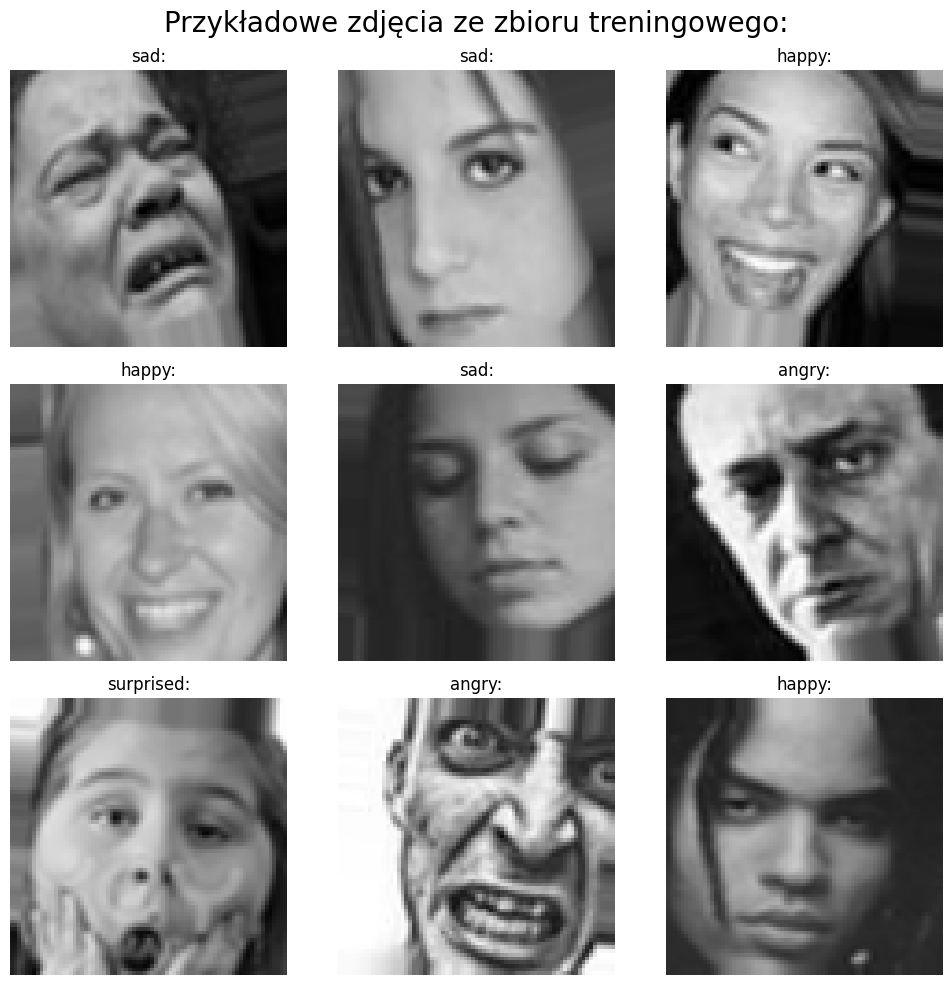

In [31]:
print(f"Classes: {train_set.class_indices}")

# Reverse the class_indices disctionary (np. 0 -> 'angry', 1 -> 'fear', ...)
class_labels = {v: k for k, v in train_set.class_indices.items()}

# Exempary images
plt.figure(figsize=(10, 10))
plt.suptitle("Przykładowe zdjęcia ze zbioru treningowego:", fontsize=20)
x_batch, y_batch = next(train_set)
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    label_index = np.argmax(y_batch[i])
    class_name = class_labels[label_index]
    plt.title(f"{class_name}:")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [32]:
# Adding class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_set.classes),
    y=train_set.classes
)
class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(1.016436358816317),
 1: np.float64(2.2606313720673135),
 2: np.float64(1.000652464685349),
 3: np.float64(0.6785511499804588),
 4: np.float64(0.8838547319687641),
 5: np.float64(0.9001966327858267),
 6: np.float64(1.164871194379391)}

In [33]:
# Face detection setup
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Function to detect and preprocess faces in images
def detect_face(image_path, target_size=(75, 75)):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4)
    if len(faces) == 0:
        return None
    x, y, w, h = faces[0]
    face = img[y:y+h, x:x+w]
    face_resized = cv2.resize(face, target_size)
    return face_resized / 255.0


def load_dataset(data_dir, target_size=(75, 75)):
    images = []
    labels = []
    class_names = sorted(os.listdir(data_dir))

    for label in class_names:
        class_dir = os.path.join(data_dir, label)
        for filename in os.listdir(class_dir):
            img_path = os.path.join(class_dir, filename)
            face = detect_face(img_path, target_size)
            if face is not None:
                images.append(face)
                labels.append(label)

    le = LabelEncoder()
    labels_encoded = le.fit_transform(labels)
    one_hot_labels = to_categorical(labels_encoded, num_classes=len(le.classes_))

    return np.array(images), one_hot_labels, le

X_train, y_train, label_encoder = load_dataset(train_path, target_size)
X_val, y_val, _ = load_dataset(test_path, target_size)
X_test, y_test, _ = load_dataset(test_path, target_size)


print("Train data:", X_train.shape, y_train.shape)
print("Test data:", X_test.shape, y_test.shape)

Train data: (57755, 75, 75, 3) (57755, 7)
Test data: (11238, 75, 75, 3) (11238, 7)


In [ ]:
model = Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(75, 75, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

c:\Users\48668\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
# Callback that changes learning rate when model has stopped improving
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_set,
    steps_per_epoch=len(train_set),
    epochs=40,
    validation_data=train_set,
    validation_steps=len(train_set),
    class_weight=class_weights,
    callbacks=[reduce_lr]
)

Epoch 1/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 5225s 2s/step - accuracy: 0.2449 - loss: 2.3302 - val_accuracy: 0.3817 - val_loss: 1.6696 - learning_rate: 1.0000e-04
Epoch 2/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 3648s 1s/step - accuracy: 0.3907 - loss: 1.6549 - val_accuracy: 0.3666 - val_loss: 1.9969 - learning_rate: 1.0000e-04
Epoch 3/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 3303s 1s/step - accuracy: 0.4781 - loss: 1.4190 - val_accuracy: 0.5582 - val_loss: 1.2621 - learning_rate: 1.0000e-04
Epoch 4/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 3314s 1s/step - accuracy: 0.5405 - loss: 1.2371 - val_accuracy: 0.5754 - val_loss: 1.1819 - learning_rate: 1.0000e-04
Epoch 5/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 3328s 1s/step - accuracy: 0.5720 - loss: 1.1438 - val_accuracy: 0.5877 - val_loss: 1.1526 - learning_rate: 1.0000e-04
Epoch 6/40
2876/2876 ━━━━━━━━━━━━━━━━━━━━ 3310s 1s/step - accuracy: 0.6040 - loss: 1.0519 - val_accuracy: 0.6332 - val_loss: 1.0566 - learning_rate: 1.0000e-04
Epoch 7/40
2876/2876 ━━━━━━━━━━━━━━━━━━━

In [45]:
loss, acc = model.evaluate(test_set)
print(f"\nAccuracy: {acc * 100:.2f}%")

567/567 ━━━━━━━━━━━━━━━━━━━━ 235s 414ms/step - accuracy: 0.7317 - loss: 0.7841

Accuracy: 74.86%


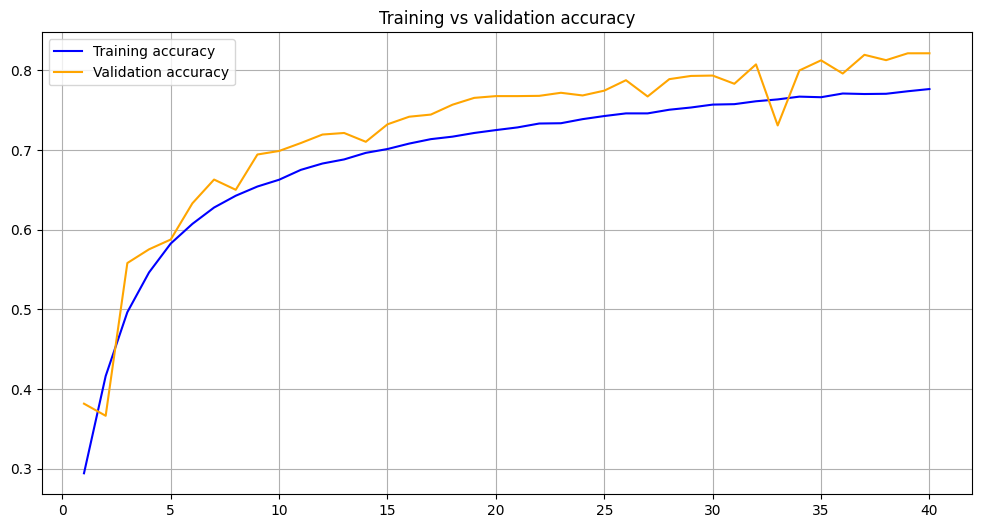

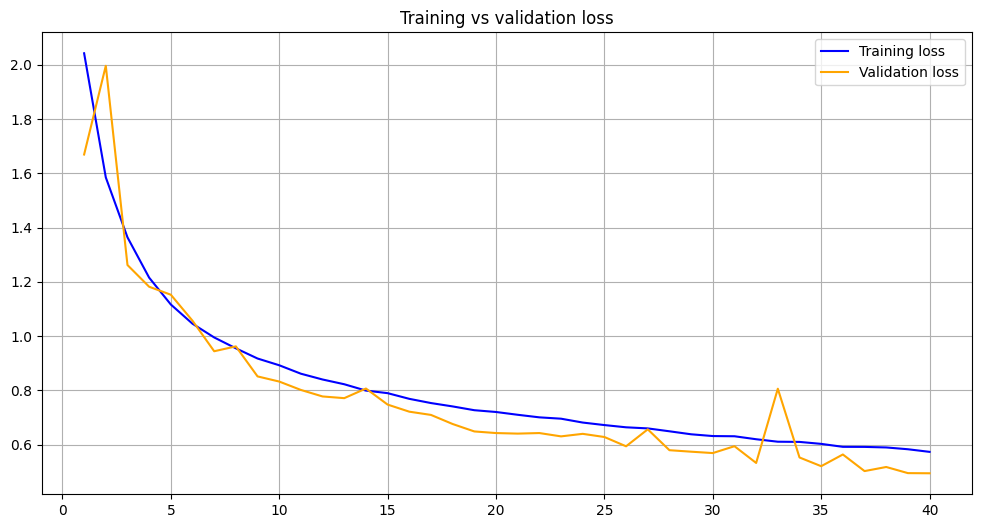

In [46]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(accuracy) + 1) # get the number of epochs for X axsis

plt.figure(figsize=(12, 6))
plt.plot(epochs, accuracy, color='blue', label='Training accuracy')
plt.plot(epochs, val_accuracy, color='orange', label='Validation accuracy')
plt.title('Training vs validation accuracy')
plt.grid(True)
plt.legend()

plt.figure(figsize=(12, 6))
plt.plot(epochs, loss, color='blue', label='Training loss')
plt.plot(epochs, val_loss, color='orange', label='Validation loss')
plt.title('Training vs validation loss')
plt.grid(True)
plt.legend()

plt.show()

In [47]:
Y_pred = model.predict(test_set)
y_pred = np.argmax(Y_pred, axis=1)
target_names = [class_labels[i] for i in range(len(class_labels))]
print(classification_report(test_set.classes, y_pred, target_names=target_names))

567/567 ━━━━━━━━━━━━━━━━━━━━ 126s 221ms/step
              precision    recall  f1-score   support

       angry       0.73      0.69      0.71      2603
   disgusted       0.93      0.92      0.93       909
        fear       0.57      0.64      0.60      1711
       happy       0.91      0.85      0.88      4235
     neutral       0.64      0.72      0.68      3153
         sad       0.70      0.58      0.64      3181
   surprised       0.77      0.91      0.84      2349

    accuracy                           0.75     18141
   macro avg       0.75      0.76      0.75     18141
weighted avg       0.75      0.75      0.75     18141



In [48]:
model.save("emotion_model_final.h5")
print("✅ Model was saved as emotion_cnn_model.h5")

✅ Model was saved as emotion_cnn_model.h5


In [49]:
limit_per_class = 100

def get_limited_dataset(root_dir, target_size=target_size, limit_per_class=limit_per_class):
    all_images = []
    all_labels = []
    class_names = sorted(os.listdir(root_dir))

    for label_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(root_dir, class_name)
        image_files = os.listdir(class_dir)
        random.shuffle(image_files)
        selected_files = image_files[:limit_per_class]

        for image_file in selected_files:
            image_path = os.path.join(class_dir, image_file)
            img = load_img(image_path, target_size=target_size)
            img_array = img_to_array(img) / 255.0
            all_images.append(img_array)
            all_labels.append(label_idx)

    return tf.convert_to_tensor(all_images), tf.convert_to_tensor(all_labels), class_names

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 199ms/step

 Raport Klasyfikacji:

              precision    recall  f1-score   support

       angry       0.72      0.78      0.75       100
   disgusted       0.92      0.94      0.93       100
        fear       0.70      0.60      0.65       100
       happy       0.85      0.77      0.81       100
     neutral       0.60      0.63      0.61       100
         sad       0.66      0.63      0.64       100
   surprised       0.78      0.87      0.82       100

    accuracy                           0.75       700
   macro avg       0.75      0.75      0.74       700
weighted avg       0.75      0.75      0.74       700



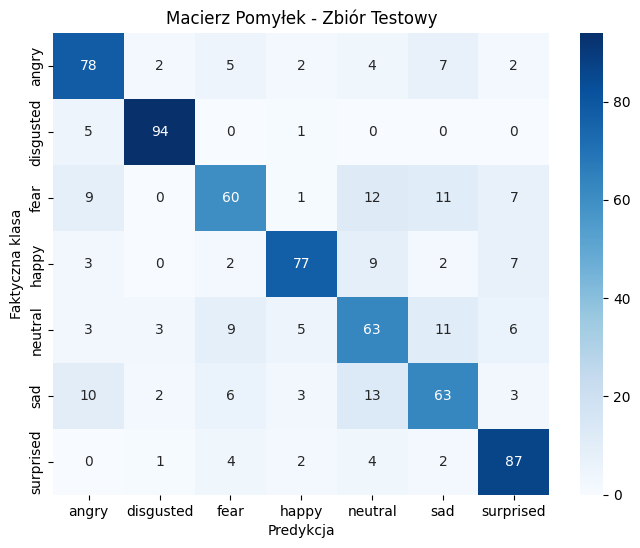

In [50]:
x_test, y_test, class_names = get_limited_dataset(r'C:\Users\48668\Documents\jdszr18-Neuronauci\Data\test', target_size=target_size, limit_per_class=limit_per_class)

preds = model.predict(x_test)
y_pred = np.argmax(preds, axis=1)
y_true = y_test.numpy()

print("\n Raport Klasyfikacji:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


confusion_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predykcja")
plt.ylabel("Faktyczna klasa")
plt.title("Macierz Pomyłek - Zbiór Testowy")
plt.show()